In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [3]:
df=pd.read_csv('dataset/weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


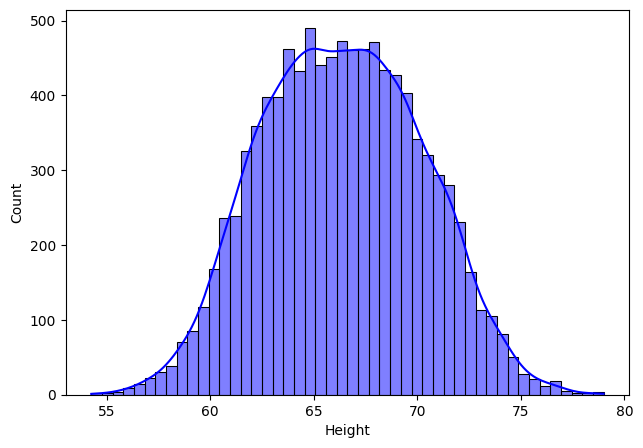

In [13]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data=df,x='Height',fill=True,label='Height',color='blue',kde=True)
plt.show()

<Axes: ylabel='Height'>

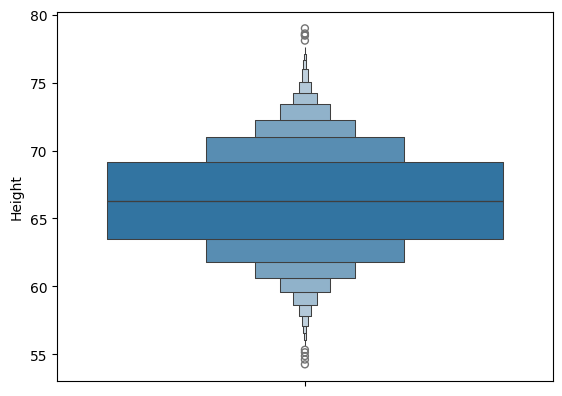

In [6]:
sns.boxenplot(df['Height'])

In [7]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [8]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [9]:
df[(df['Height']>upper_limit) | (df['Height']<lower_limit)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [11]:
new_df = df[(df['Height']<=upper_limit) & (df['Height']>lower_limit)]
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [12]:
new_df['Height'].describe()

count    9800.000000
mean       66.364366
std         3.645075
min        58.134496
25%        63.577162
50%        66.318070
75%        69.119896
max        74.785714
Name: Height, dtype: float64

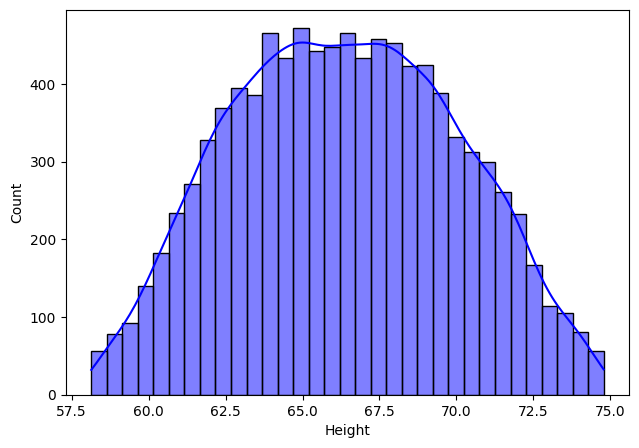

In [14]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data=new_df,x='Height',fill=True,label='Height',color='blue',kde=True)
plt.show()

<Axes: xlabel='Height'>

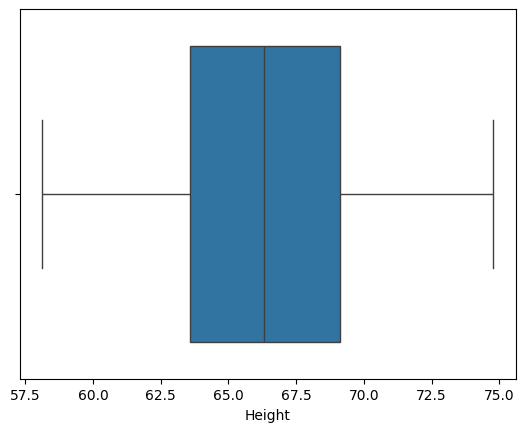

In [15]:
sns.boxplot(x=new_df['Height'])

### Capping (Winsorization)

In [17]:
df['Height']=np.where(df['Height']>=upper_limit,upper_limit,np.where(df['Height']<=lower_limit,lower_limit,df['Height']))

In [19]:
df.shape

(10000, 3)

In [20]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.366281,161.440357
std,3.795717,32.108439
min,58.134412,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,74.785790,269.989699


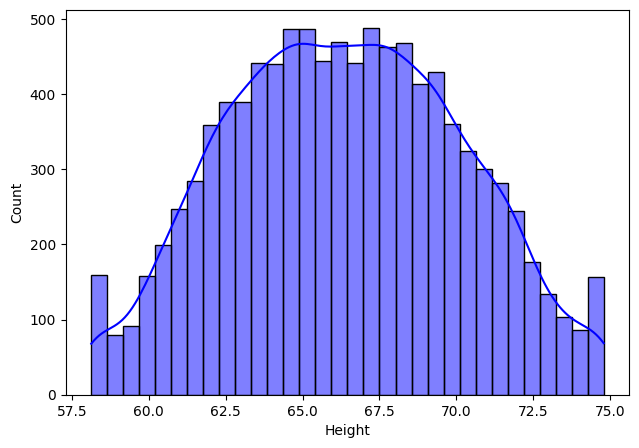

In [21]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data=df,x='Height',fill=True,label='Height',color='blue',kde=True)
plt.show()

<Axes: xlabel='Height'>

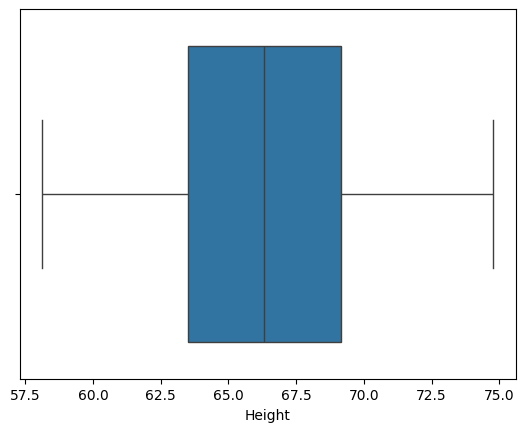

In [22]:
sns.boxplot(x=df['Height'])